# Final Experiments: Binary Pneumonia Classification

**Task.** Classify pediatric chest X-rays as **NORMAL** vs **PNEUMONIA** (binary), on the Kermany *Chest X-Ray Images (Pneumonia)* dataset (≈5.8k images, distributed on Kaggle by Paul Mooney).

**Approach.** We compare three models under identical training/evaluation:

| Model | Role | Why |
|---|---|---|
| **Custom CNN** | from-scratch baseline | lower-bound reference; shows the value of transfer learning |
| **ResNet18** | ImageNet-pretrained backbone | residual connections, strong + lightweight |
| **DenseNet121** | ImageNet-pretrained backbone | dense connectivity; our **primary** model |

**Protocol.** Each model is trained with **3 seeds (0, 1, 2)** for reproducibility; transfer models use a two-phase schedule (5 head-only epochs → fine-tuning with early stopping). We report **mean ± std** across seeds, and also build an **ensemble** (averaged probabilities of ResNet18 + DenseNet121). Hardware: NVIDIA RTX 3060 Laptop GPU.

**What this notebook shows.** Training histories & curves, per-model and ensemble test metrics, comparison plots, and Grad-CAM explanations. The three-class extension (NORMAL/BACTERIA/VIRUS), hierarchical model and calibration live in `02_innovation_results.ipynb`.

> **Note on metrics.** Pneumonia **recall** is emphasised: in screening, a missed pneumonia (false negative) is clinically more costly than a false alarm. Figures/metrics are produced by the scripts in `scripts/` (the `run_binary.ps1` pipeline runs them end-to-end).

## 1. Setup

In [174]:
import json
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path('..') / 'src'))

METRICS_DIR = Path('../results/metrics')
FIGURES_DIR = Path('../results/figures')
CHECKPOINTS_DIR = Path('../results/checkpoints')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1b. Model Architectures

The two transfer-learning backbones differ in how they reuse features:

- **ResNet** uses *residual* (skip) connections that add a block's input to its output ($x + F(x)$), which eases gradient flow in deep networks.
- **DenseNet** instead *concatenates* each layer's output with all preceding feature maps, maximising feature reuse with fewer parameters: our primary model.

Conceptual illustrations below (figures from the Vizuara explainers; the ResNet image-restoration example is illustrative of skip connections only).

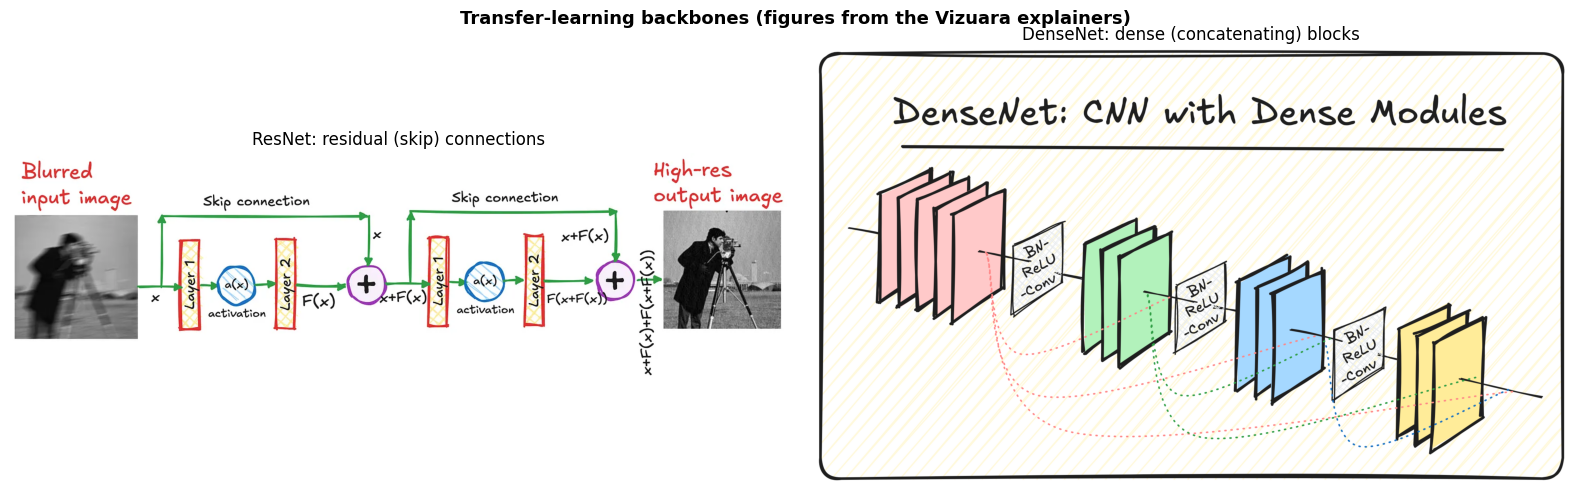

In [175]:
import matplotlib.image as mpimg

# Architecture illustrations live alongside the report .tex file
ARCH_DIR = Path("../reports/Final Project Report")
arch_figs = [
    ("ResNet: residual (skip) connections", "resnet-explanation.png"),
    ("DenseNet: dense (concatenating) blocks", "densenet-explanation.png"),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (title, fname) in zip(axes, arch_figs):
    path = ARCH_DIR / fname
    if path.exists():
        ax.imshow(mpimg.imread(path))
    else:
        ax.text(0.5, 0.5, "missing: " + fname, ha="center", va="center", fontsize=9)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.suptitle("Transfer-learning backbones (figures from the Vizuara explainers)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Load Training Histories

In [176]:
import json
from pathlib import Path

METRICS_DIR = Path("../results/metrics")  # also defined in Setup; repeated so this cell is self-contained

def load_history(model_name, seed, suffix='history'):
    path = METRICS_DIR / f'{model_name}_seed{seed}_{suffix}.json'
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)

histories = {}

for seed in [0, 1, 2]:
    # custom_cnn has a single history file
    h = load_history('custom_cnn', seed)
    key = f'custom_cnn_seed{seed}'
    if h:
        histories[key] = h
        n_epochs = len(h['history'])
        best_epoch = h['best_epoch']
        best_loss = h['best_val_loss']
        print(f"{key}: {n_epochs} epochs, best epoch {best_epoch}, best val_loss {best_loss:.4f}")
    else:
        print(f"{key}: NOT YET TRAINED")

for model in ['resnet18', 'densenet121']:
    for seed in [0, 1, 2]:
        # transfer models have separate head_only and fine_tune history files
        h = load_history(model, seed, suffix='fine_tune_history')
        key = f'{model}_seed{seed}'
        if h:
            histories[key] = h
            n_epochs = len(h['history'])
            best_epoch = h['best_epoch']
            best_loss = h['best_val_loss']
            print(f"{key}: {n_epochs} fine-tune epochs, best epoch {best_epoch}, best val_loss {best_loss:.4f}")
        else:
            print(f"{key}: NOT YET TRAINED")

custom_cnn_seed0: 9 epochs, best epoch 4, best val_loss 0.5781
custom_cnn_seed1: 6 epochs, best epoch 1, best val_loss 0.7687
custom_cnn_seed2: 12 epochs, best epoch 7, best val_loss 0.6519
resnet18_seed0: 13 fine-tune epochs, best epoch 8, best val_loss 0.1278
resnet18_seed1: 10 fine-tune epochs, best epoch 5, best val_loss 0.1117
resnet18_seed2: 11 fine-tune epochs, best epoch 6, best val_loss 0.0334
densenet121_seed0: 23 fine-tune epochs, best epoch 18, best val_loss 0.0155
densenet121_seed1: 12 fine-tune epochs, best epoch 7, best val_loss 0.0329
densenet121_seed2: 11 fine-tune epochs, best epoch 6, best val_loss 0.0465


## 3. Training Curves

Per-seed loss and validation-F1 curves (generated by `scripts/generate_plots_binary.py`), shown as a grid: one column per seed, one row per training phase. These reveal **how** each model learns, not just the final score:

- The **custom CNN** (single phase) overfits quickly: train loss keeps dropping while val loss plateaus or rises, so early stopping fires after a few epochs.
- The **transfer models** have two phases, *head-only* (backbone frozen) then *fine-tune* (full network), and converge faster and to a lower val loss, because the ImageNet features are already useful.

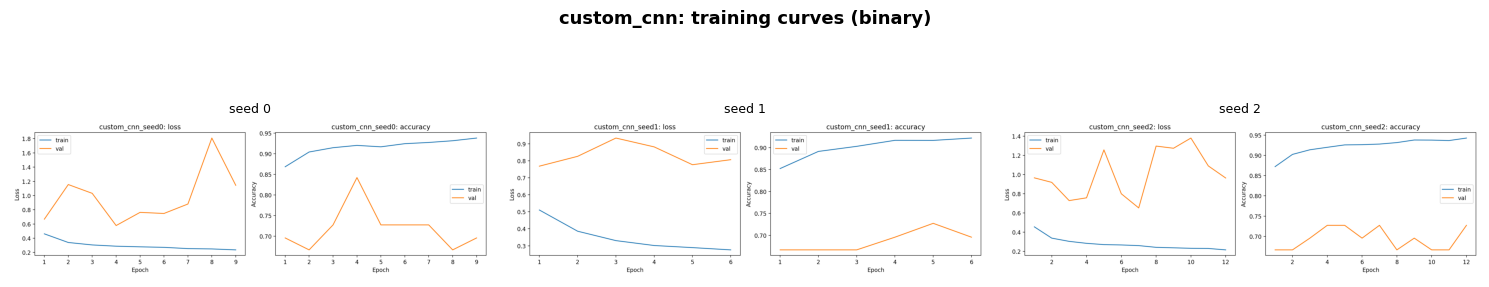

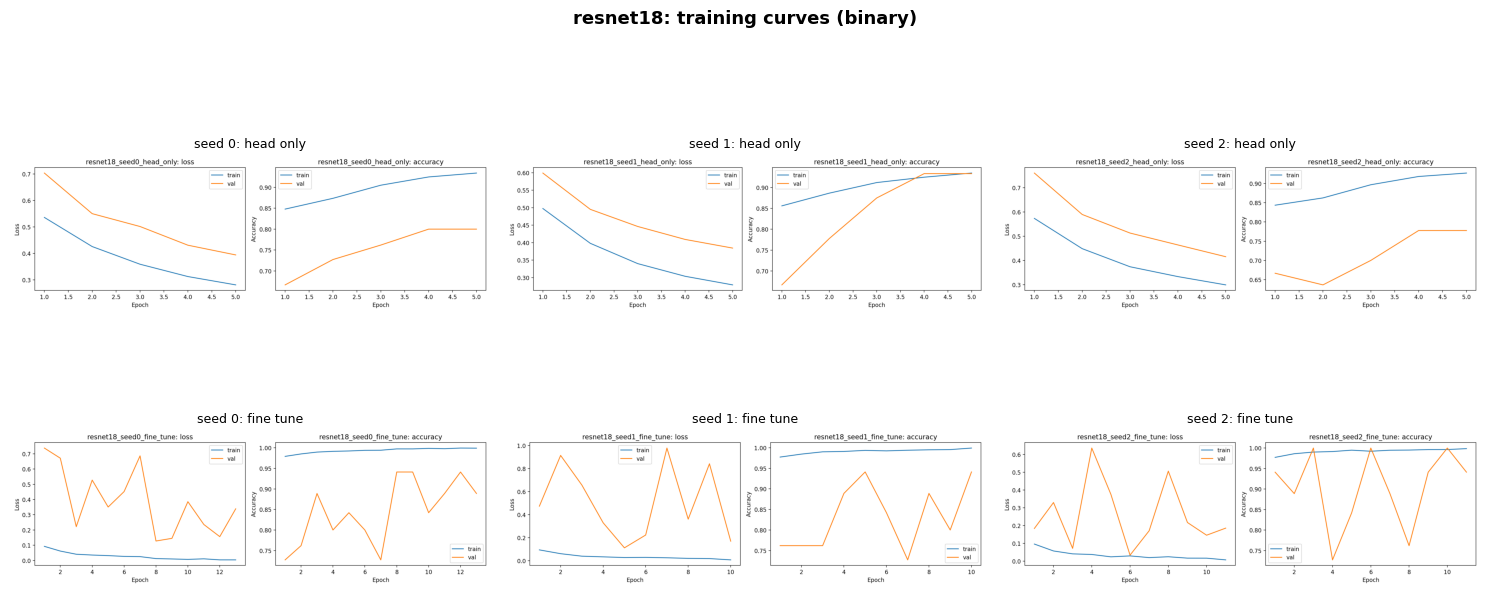

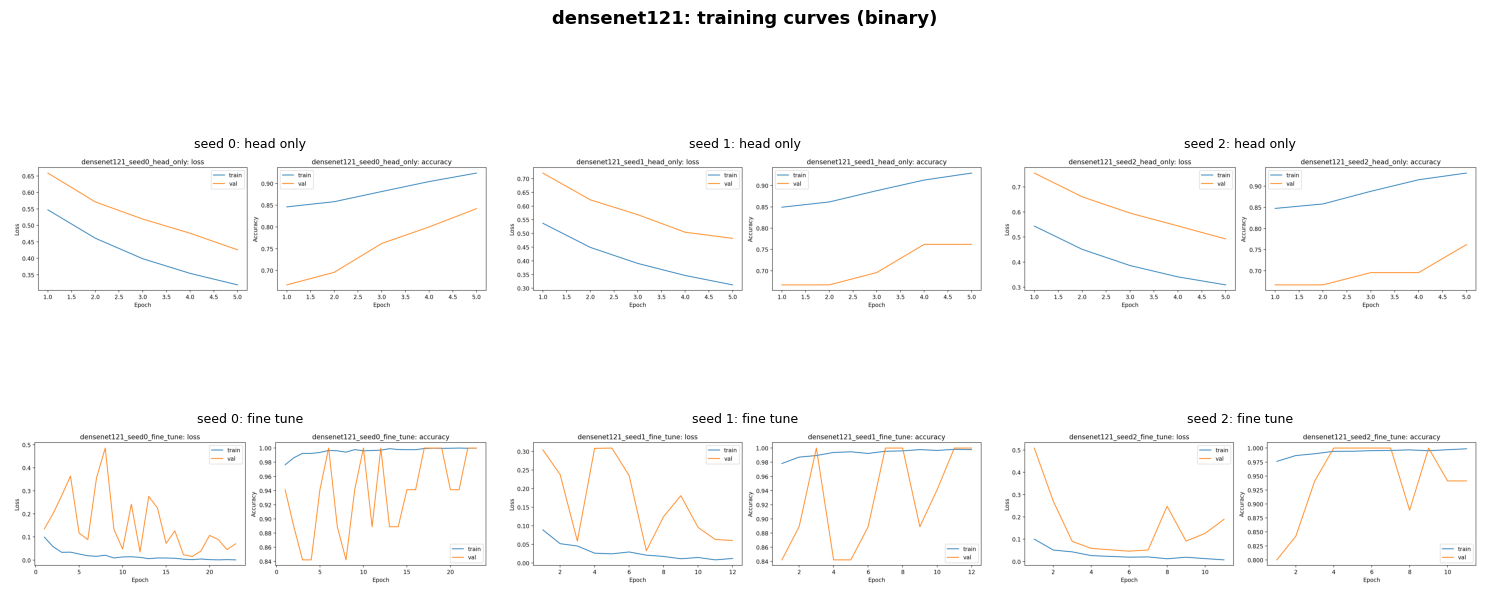

In [177]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from pathlib import Path

FIGURES_DIR = Path("../results/figures")  # also defined in Setup; repeated so this cell is self-contained

# Training-curve PNGs generated by scripts/generate_plots_binary.py
# The baseline trains in a single phase, while the transfer models have two phases (head-only -> fine-tune)
SEEDS = [0, 1, 2]

def show_curve_grid(model, phases):
    fig, axes = plt.subplots(len(phases), len(SEEDS), figsize=(5 * len(SEEDS), 3.6 * len(phases)))
    axes = np.atleast_2d(axes)
    fig.suptitle(f"{model}: training curves (binary)", fontsize=13, fontweight="bold")
    for r, phase in enumerate(phases):
        for c, seed in enumerate(SEEDS):
            suffix = f"{phase}_" if phase else ""
            path = FIGURES_DIR / f"{model}_seed{seed}_{suffix}training_curves.png"
            ax = axes[r][c]
            if path.exists():
                ax.imshow(mpimg.imread(path))
            else:
                ax.text(0.5, 0.5, "not found", ha="center", va="center", fontsize=8)
            title = f"seed {seed}" + (f": {phase.replace('_', ' ')}" if phase else "")
            ax.set_title(title, fontsize=9)
            ax.axis("off")
    plt.tight_layout()
    plt.show()

# custom_cnn: single phase (empty string -> "<model>_seed<seed>_training_curves.png")
show_curve_grid("custom_cnn", [""])
# transfer models: head-only + fine-tune
show_curve_grid("resnet18", ["head_only", "fine_tune"])
show_curve_grid("densenet121", ["head_only", "fine_tune"])

## 4. Custom CNN: Training Summary

Trained on NVIDIA RTX 3060 Laptop GPU.

| Seed | Epochs run | Best epoch | Best val loss | Best val F1 |
|------|------------|------------|---------------|-------------|
| 0    | 9          | 4          | 0.5781        | 0.8421      |
| 1    | 6          | 1          | 0.7687        | 0.6667      |
| 2    | 12         | 7          | 0.6519        | 0.7273      |

Early stopping fired in all runs. The model overfits quickly due to its small capacity. Transfer-learning models are expected to generalise significantly better.

## 5. ResNet18: Training Summary

Trained on NVIDIA RTX 3060 Laptop GPU. Two-phase training: 5 head-only epochs + fine-tuning with early stopping.

| Seed | Fine-tune epochs run | Best fine-tune epoch | Best val loss | Best val F1 |
|------|----------------------|----------------------|---------------|-------------|
| 0    | 13                   | 8                    | 0.1278        | 0.9412      |
| 1    | 10                   | 5                    | 0.1117        | 0.9412      |
| 2    | 11                   | 6                    | 0.0334        | 1.0000      |

Seed 2 achieved perfect val F1 (1.0) with the lowest val loss. It's the best checkpoint for upload.

## 6. DenseNet121: Training Summary

Trained on NVIDIA RTX 3060 Laptop GPU. Two-phase training: 5 head-only epochs + fine-tuning with early stopping.

| Seed | Fine-tune epochs run | Best fine-tune epoch | Best val loss | Best val F1 |
|------|----------------------|----------------------|---------------|-------------|
| 0    | 23                   | 18                   | 0.0155        | 1.0000      |
| 1    | 12                   | 7                    | 0.0329        | 1.0000      |
| 2    | 11                   | 6                    | 0.0465        | 1.0000      |

All three seeds reach a perfect **validation** F1; seed 0 has the lowest val loss and is the checkpoint we upload.

> **Caveat (read with care).** The Kaggle *binary* `val/` folder has only **16 images**, so a val F1 of 1.0 is easy to hit and is **not** a reliable estimate of generalisation. It just means the model separates those 16 cases. The honest performance number is the **test set** (624 patients), reported in §8. (For the three-class task in notebook 02 we fix this with a proper patient-aware validation split.)

## 7. Push Best Binary Checkpoints to Hugging Face

The trained weights (`.pt`) total ~1.5 GB and are **git-ignored** (too large for the repo). We publish the best **binary** checkpoint per model to the **Hugging Face Hub** so they can be downloaded and reused without retraining. They are stored under `checkpoints/binary/`. (The three-class and hierarchical models are uploaded from notebook 02.)

Install and authenticate once:
```bash
pip install huggingface_hub
huggingface-cli login
```

In [178]:
from huggingface_hub import HfApi, create_repo

HF_REPO_ID = 'luanacarolina/pneumonia-chest-xray-classifier'

api = HfApi()
create_repo(HF_REPO_ID, exist_ok=True)

# Binary-task checkpoints only (the three-class / hierarchical models are
# uploaded from notebook 02). The .pt weights are ~1.5 GB total and are
# git-ignored, so the Hugging Face Hub is where we share them for reuse /
# reproducibility without retraining (one best seed per model)
checkpoints_to_upload = {
    'binary/custom_cnn.pt':  'custom_cnn_seed0.pt',    # baseline
    'binary/resnet18.pt':    'resnet18_seed2.pt',      # best binary val
    'binary/densenet121.pt': 'densenet121_seed0.pt',   # primary binary model
}

for repo_path, filename in checkpoints_to_upload.items():
    local_path = CHECKPOINTS_DIR / filename
    if not local_path.exists():
        print(f'SKIP {filename} -> not found locally')
        continue
    api.upload_file(
        path_or_fileobj=str(local_path),
        path_in_repo=f'checkpoints/{repo_path}',
        repo_id=HF_REPO_ID,
        repo_type='model',
    )
    print(f'Uploaded: {filename} -> {HF_REPO_ID}/checkpoints/{repo_path}')

Processing Files (1 / 1): 100%|██████████| 1.14MB / 1.14MB,   ???B/s  
New Data Upload: |          |  0.00B /  0.00B,   ???B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded: custom_cnn_seed0.pt -> luanacarolina/pneumonia-chest-xray-classifier/checkpoints/binary/custom_cnn.pt


Processing Files (1 / 1): 100%|██████████|  134MB /  134MB,   ???B/s  
New Data Upload: |          |  0.00B /  0.00B,   ???B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded: resnet18_seed2.pt -> luanacarolina/pneumonia-chest-xray-classifier/checkpoints/binary/resnet18.pt


Processing Files (1 / 1): 100%|██████████| 84.4MB / 84.4MB,   ???B/s  
New Data Upload: |          |  0.00B /  0.00B,   ???B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded: densenet121_seed0.pt -> luanacarolina/pneumonia-chest-xray-classifier/checkpoints/binary/densenet121.pt


---

## 8. Final Results Table (test set)

Aggregated metrics from `scripts/make_result_tables.py --task binary` (one row per model, already mean ± std over seeds).

**What to look for:**
- **Transfer learning ≫ from scratch:** both ResNet18 and DenseNet121 clearly beat the custom CNN on every metric, with much lower variance across seeds.
- **DenseNet121 is the best single model** (highest F1 and AUROC) and is our primary model.
- **Pneumonia recall is ~0.99** for the transfer models. Critical for a screening setting, where missing a sick child is the costly error. The trade-off is lower specificity (more false alarms on normal lungs).
- **The ensemble** (ResNet18 + DenseNet121) gives the best overall accuracy/F1, by reducing per-seed variance.

In [179]:
import pandas as pd
from pathlib import Path
from IPython.display import display

METRICS_DIR = Path("../results/metrics")  # also defined in Setup; repeated so this cell is self-contained

# final_results.csv is ALREADY aggregated (one row per model, with *_mean / *_std
# columns), so we just format it as "mean ± std": no further groupby needed
final_results_path = METRICS_DIR / "final_results.csv"

if not final_results_path.exists():
    print(f"Not found: {final_results_path}\nRun:  python scripts/make_result_tables.py --task binary")
else:
    raw = pd.read_csv(final_results_path, index_col=0)
    metrics = ["accuracy", "precision", "recall", "specificity", "f1", "auroc",
               "inference_time_ms_per_image"]
    pretty = {"accuracy": "Accuracy", "precision": "Precision", "recall": "Recall",
              "specificity": "Specificity", "f1": "F1", "auroc": "AUROC",
              "inference_time_ms_per_image": "Inference (ms/img)"}

    table = pd.DataFrame(index=raw.index)
    for m in metrics:
        mean_c, std_c = f"{m}_mean", f"{m}_std"
        if mean_c not in raw.columns:
            continue
        def fmt(r, mean_c=mean_c, std_c=std_c):
            mean = r[mean_c]
            std = r.get(std_c)
            if pd.isna(mean):
                return "-"
            return f"{mean:.4f}" if pd.isna(std) else f"{mean:.4f} ± {std:.4f}"
        table[pretty[m]] = raw.apply(fmt, axis=1)

    # Order: baseline, transfer models, ensemble
    order = ["custom_cnn", "resnet18", "densenet121", "ensemble_resnet18_densenet121"]
    table = table.reindex([m for m in order if m in table.index])
    print("Binary test-set results: mean ± std across seeds (ensemble is deterministic)")
    display(table)

Binary test-set results: mean ± std across seeds (ensemble is deterministic)


,Accuracy,Precision,Recall,Specificity,F1,AUROC,Inference (ms/img)
model,,,,,,,
custom_cnn,0.7564 ± 0.0902,0.7682 ± 0.1102,0.9137 ± 0.0758,0.4943 ± 0.3594,0.8275 ± 0.0404,0.8859 ± 0.0156,14.1204 ± 1.3815
resnet18,0.8296 ± 0.0184,0.7905 ± 0.0205,0.9906 ± 0.0053,0.5613 ± 0.0558,0.8792 ± 0.0111,0.9491 ± 0.0047,14.8943 ± 0.5175
densenet121,0.8408 ± 0.0198,0.7990 ± 0.0202,0.9966 ± 0.0015,0.5812 ± 0.0534,0.8868 ± 0.0124,0.9664 ± 0.0065,15.9532 ± 0.3835
ensemble_resnet18_densenet121,0.8558,0.8138,0.9974,0.6197,0.8963,0.9630,-


In [180]:
import json
from pathlib import Path

METRICS_DIR = Path("../results/metrics")  # also defined in Setup; repeated so this cell is self-contained

# Headline clinical numbers for the binary ensemble
# (The confusion-matrix figure itself is shown in section 9.)
ens = json.load(open(METRICS_DIR / "ensemble_resnet18_densenet121.json"))
cmd = ens["confusion_matrix"]  # keys: tn, fp, fn, tp

# Pull values into plain variables so the f-strings below have no nested quotes
recall = ens["recall"]
specificity = ens["specificity"]
missed = cmd["fn"]
total_pneumonia = cmd["fn"] + cmd["tp"]
false_alarms = cmd["fp"]

print("Binary ensemble (test set):")
print(f"  Recall (sensitivity): {recall:.4f}  ->  only {missed} pneumonia case missed out of {total_pneumonia}")
print(f"  Specificity         : {specificity:.4f}  ->  {false_alarms} normal lungs flagged as pneumonia (false alarms)")

Binary ensemble (test set):
  Recall (sensitivity): 0.9974  ->  only 1 pneumonia case missed out of 390
  Specificity         : 0.6197  ->  89 normal lungs flagged as pneumonia (false alarms)


## 9. Comparison Plots

All binary confusion matrices (every model × seed, plus the ensemble), followed by the per-metric comparison across models. Figures generated by `scripts/generate_plots_binary.py`. (The class distribution is shown in notebook 00.)

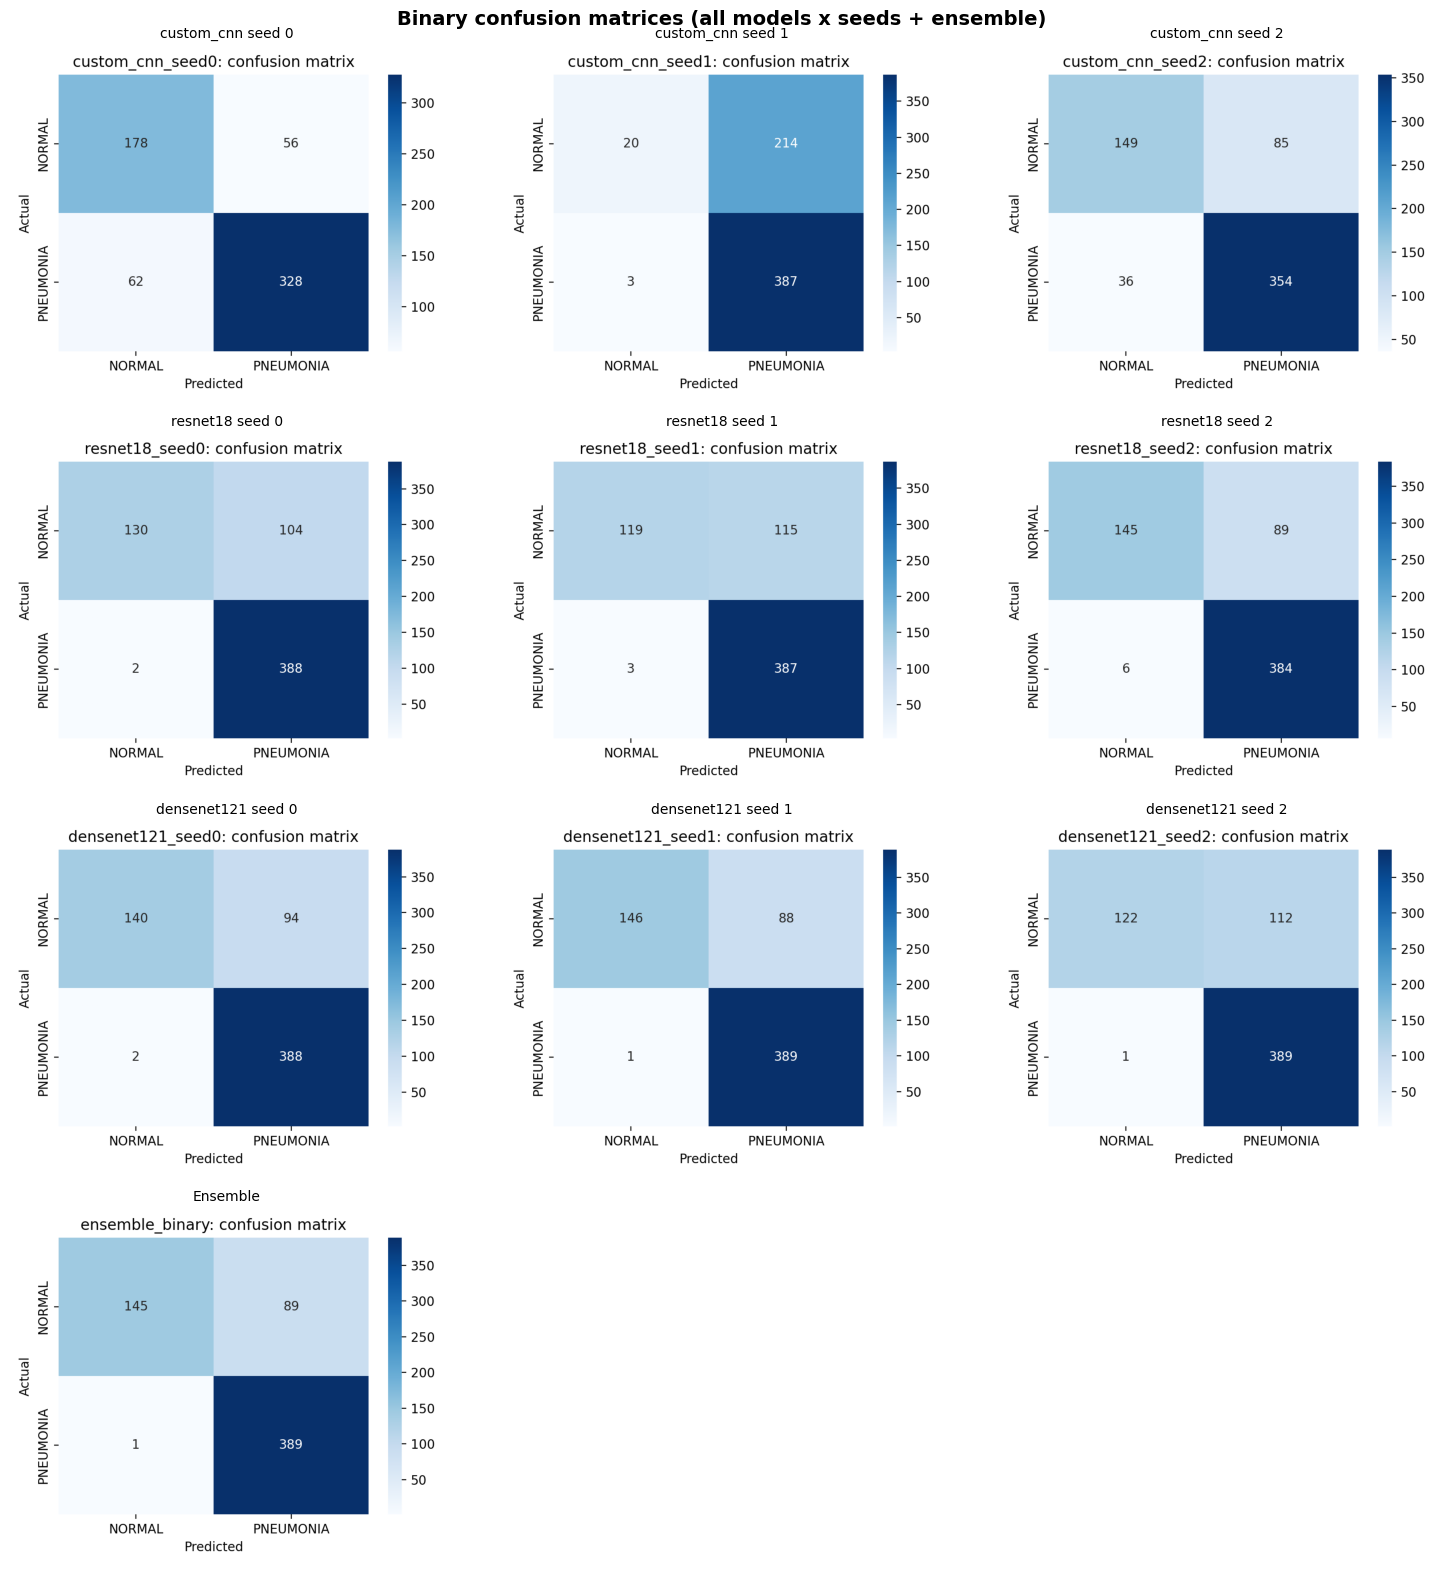

Per-metric comparison (all models)


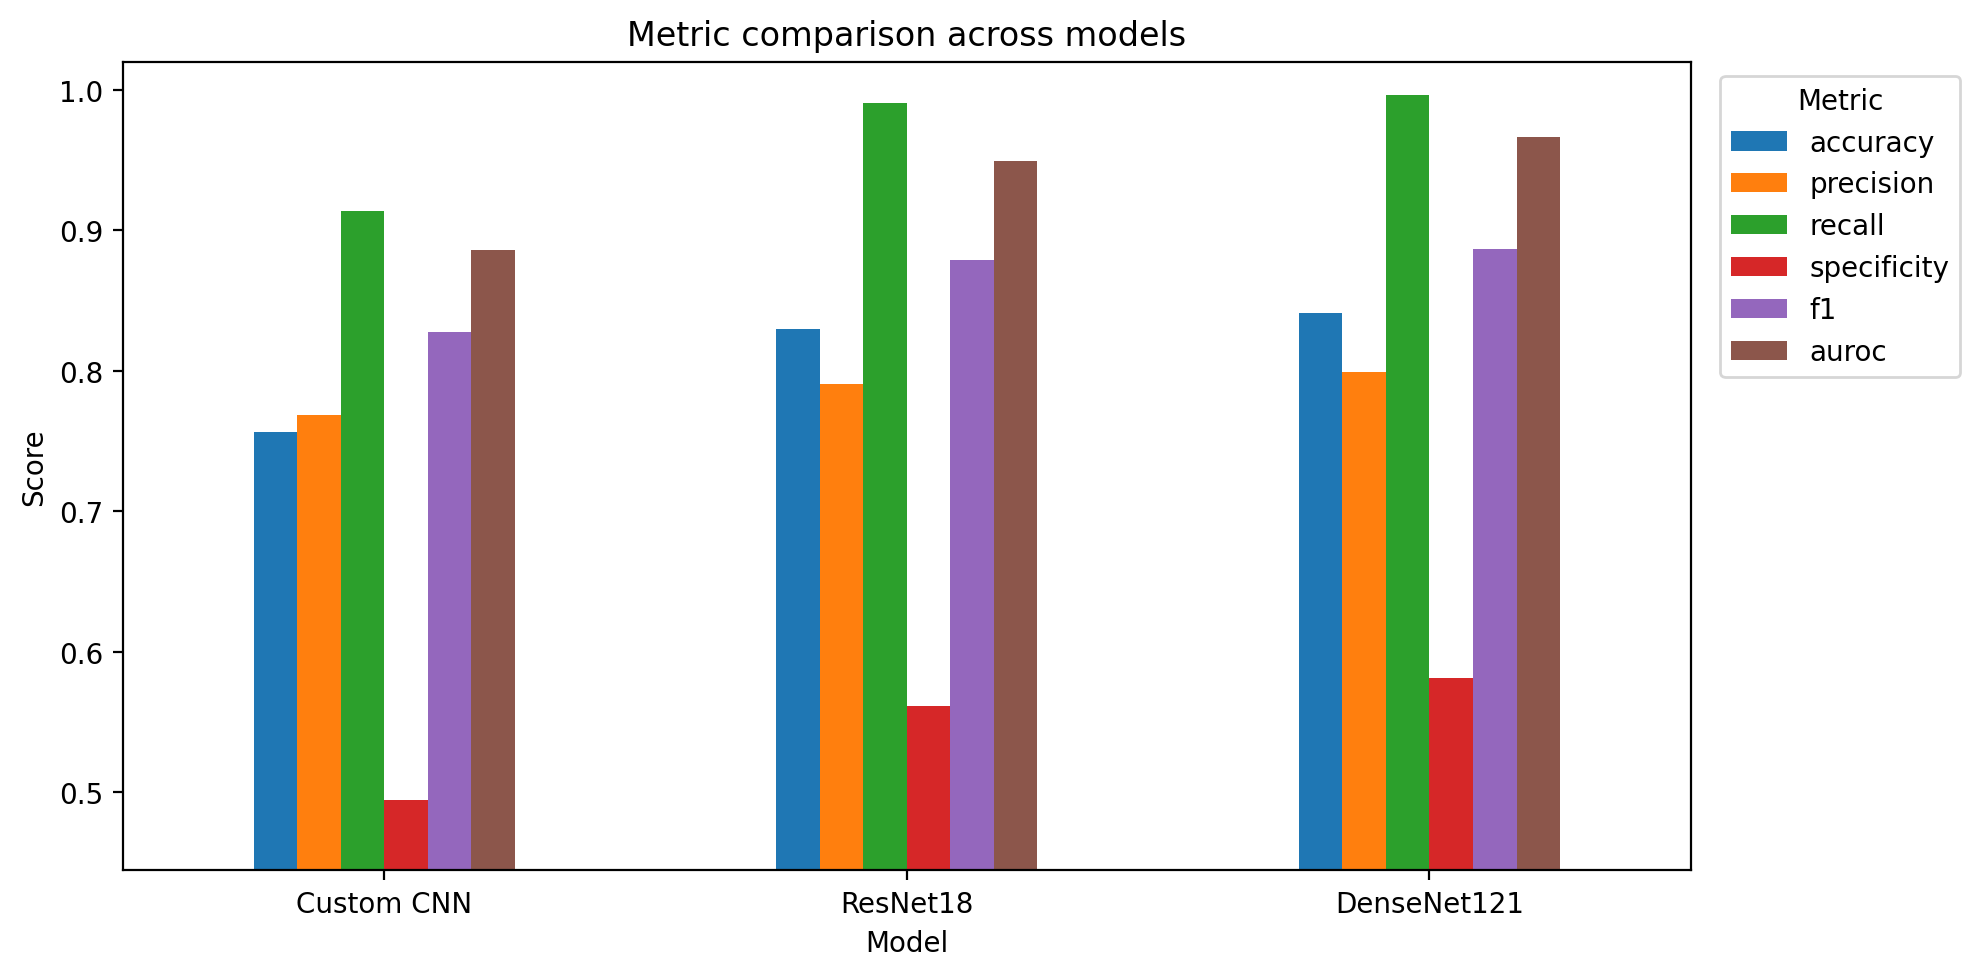

In [181]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from pathlib import Path
from IPython.display import Image as IPImage, display as ipy_display

FIGURES_DIR = Path("../results/figures")  # also defined in Setup; repeated so this cell is self-contained

# All binary confusion matrices: each model x seed, plus the ensemble.
cm_imgs = []
for model in ["custom_cnn", "resnet18", "densenet121"]:
    for seed in [0, 1, 2]:
        cm_imgs.append((f"{model} seed {seed}", FIGURES_DIR / f"{model}_seed{seed}_confusion_matrix.png"))
cm_imgs.append(("Ensemble", FIGURES_DIR / "ensemble_binary_confusion_matrix.png"))

cols = 3
rows = (len(cm_imgs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
all_axes = np.array(axes).flatten()
for i, (title, path) in enumerate(cm_imgs):
    ax = all_axes[i]
    if path.exists():
        ax.imshow(mpimg.imread(path))
        ax.set_title(title, fontsize=10)
    else:
        ax.text(0.5, 0.5, "missing", ha="center", va="center", fontsize=8)
    ax.axis("off")
for ax in all_axes[len(cm_imgs):]:
    ax.set_visible(False)
plt.suptitle("Binary confusion matrices (all models x seeds + ensemble)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Per-metric comparison across all models. (Class distribution is shown in notebook 00.)
metric_path = FIGURES_DIR / "metric_comparison_binary.png"
if metric_path.exists():
    print("Per-metric comparison (all models)")
    ipy_display(IPImage(filename=str(metric_path), width=600))
else:
    print(f"[missing] metric comparison: {metric_path}")

## 10. Grad-CAM Examples

Grad-CAM overlays for the four binary outcome types (TP, TN, FP, FN), shown as
a grid with one row per model (DenseNet121 and ResNet18). Generated by
`scripts/generate_gradcam.py`.

Run once to produce them (both models):
```bash
python scripts/generate_gradcam.py --model densenet121 --checkpoint results/checkpoints/densenet121_seed0.pt
python scripts/generate_gradcam.py --model resnet18    --checkpoint results/checkpoints/resnet18_seed0.pt
```
(The `run_binary.ps1` pipeline already generates both.)

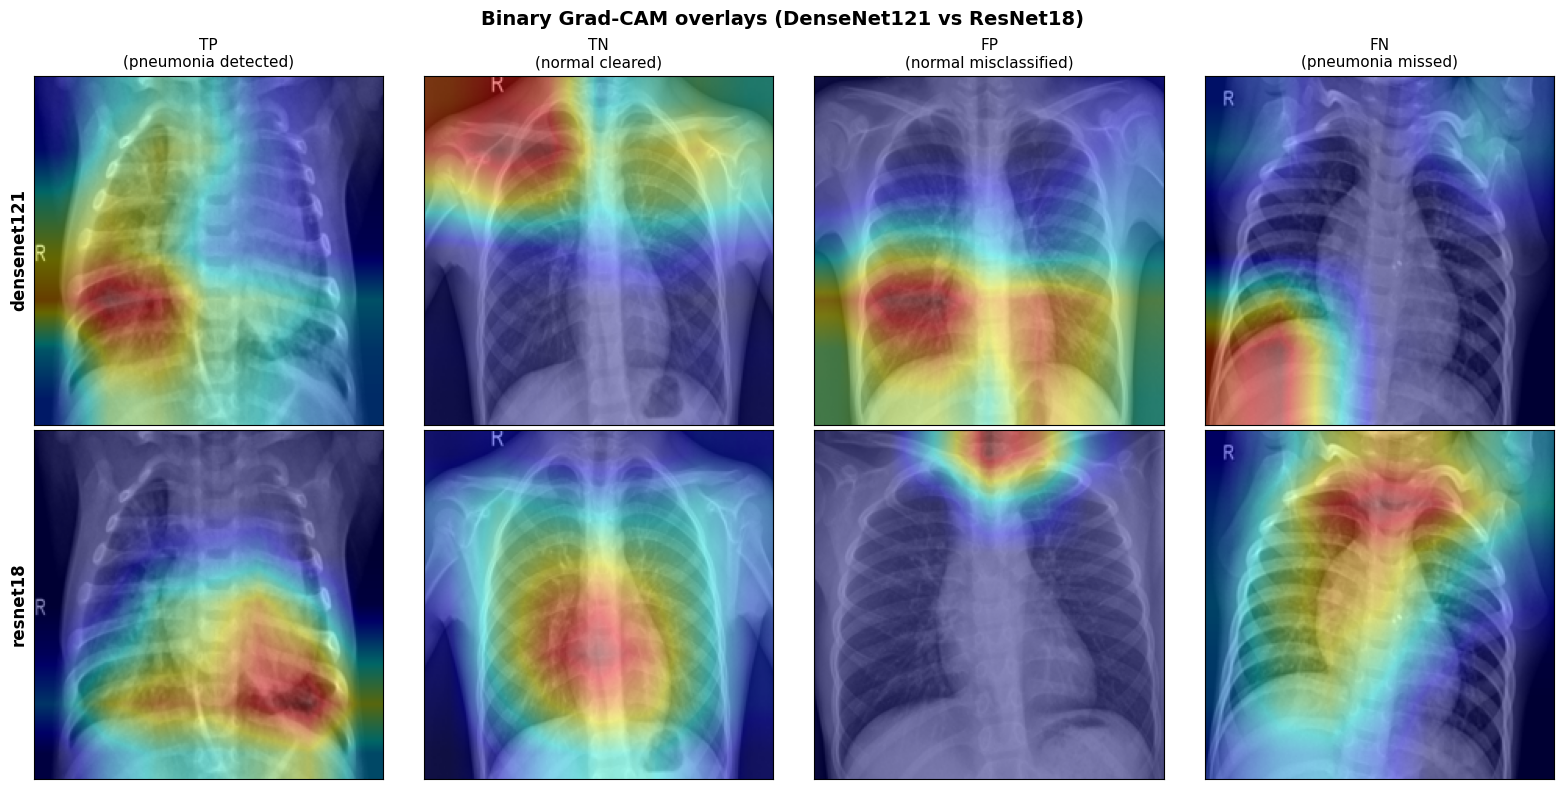

In [182]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

GRADCAM_DIR = Path('../results/gradcam')

# Binary Grad-CAM grid: rows = models, columns = outcome types (TP, TN, FP, FN)
# Filenames produced by generate_gradcam.py, e.g.
#   densenet121_true_positive_pneumonia_<stem>.png
#   resnet18_false_positive_normal_<stem>.png
MODELS = ['densenet121', 'resnet18']
OUTCOMES = [
    ('true_positive', 'TP\n(pneumonia detected)'),
    ('true_negative', 'TN\n(normal cleared)'),
    ('false_positive', 'FP\n(normal misclassified)'),
    ('false_negative', 'FN\n(pneumonia missed)'),
]

def find_binary_gradcam(model, outcome):
    # Match the model + outcome, excluding the 3-class overlays
    matches = [
        p for p in sorted(GRADCAM_DIR.glob(f'{model}_{outcome}_*.png'))
        if '_3class_' not in p.name
    ]
    return matches[0] if matches else None

fig, axes = plt.subplots(len(MODELS), len(OUTCOMES), figsize=(16, 8))
for r, model in enumerate(MODELS):
    for c, (outcome, title) in enumerate(OUTCOMES):
        ax = axes[r][c]
        path = find_binary_gradcam(model, outcome)
        if path is not None:
            ax.imshow(mpimg.imread(path))
        else:
            ax.text(0.5, 0.5, 'missing', ha='center', va='center')
        if r == 0:
            ax.set_title(title, fontsize=11)
        if c == 0:
            ax.set_ylabel(model, fontsize=12, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Binary Grad-CAM overlays (DenseNet121 vs ResNet18)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Grad-CAM Analysis

### DenseNet121

**TP: pneumonia correctly detected**

The focus (red/yellow) concentrates on the lower-left lobe, exactly over a region of visible opacification, precisely where a bacterial lobar consolidation would be expected. The evidence the network used *is* the pathology itself, so the decision is clinically auditable: a radiologist looking at this heatmap would agree on both the label and the location. This is the ideal behaviour for a screening tool.

**TN: normal correctly rejected**

The activation spreads across the shoulder and upper chest, away from the lung fields, with no focal hot-spot. This is the correct response to a normal case: there is no infiltrate to highlight, so the network's attention drifts to clinically irrelevant background. Crucially, it does **not** invent a finding inside clear lungs. The absence of focal lung activation is itself the right signal.

**FP: normal misclassified as pneumonia**

The focus falls on the lower/central lungs, overlapping the cardiac silhouette. The model mistook the heart shadow (or a normal vascular density) for a consolidation. This is an *interpretable* error: we can see exactly which normal structure was confused for pathology, which is reassuring even when the label is wrong. It points to a concrete, fixable confounder rather than random noise.

**FN: pneumonia not detected**

The heat lies on the left base (diaphragmatic zone), weak and poorly localised, and misses the true consolidation region. The most likely cause is that the opacity is subtle or atypical in this pediatric image, so the network found no strong evidence to flag. The faint, off-target attention is consistent with (and explains) why this case was missed.

---

### ResNet18 (comparison)

**TP: pneumonia correctly detected**

The heat sits on the central spine and mediastinum rather than on the lung parenchyma where the infiltrate actually is. So although the prediction is correct, the evidence the network relied on is **not** the pathology itself. It likely keyed on a correlated global cue (e.g. overall image density). A radiologist could not use this heatmap to confirm the finding.

**TN: normal correctly rejected**

Counter-intuitively, the strongest activation is in the lower/cardiac region, *inside* the lungs, even though the case is normal. This is the most concerning pattern: a correct label produced for the wrong reason. It suggests the "normal" decision is driven by the absence of a strong global signal rather than by genuinely inspecting clear lung fields.

**FP: normal misclassified as pneumonia**

Activation is faint and sits at the lower base, almost outside the lung fields. There is no coherent region of evidence, so the false alarm cannot be traced to a specific structure. The decision appears poorly grounded rather than caused by an identifiable confounder (unlike DenseNet, which at least latched onto the cardiac silhouette).

**FN: pneumonia not detected**

The heat is diffuse and spread across the whole chest with no clear focus, so the network never concentrated on the consolidation it should have detected. A scattered, low-contrast attention map like this is consistent with a missed finding: there was no localised evidence driving a "pneumonia" decision.

---

### Conclusion

| | DenseNet121 | ResNet18 |
|---|---|---|
| **TP** | Clinically plausible focus (lower lobe) | Focus on mediastinum/spine, not the infiltrate |
| **TN** | Activation outside the lungs (correct) | Activation inside the lungs (right answer, wrong reason) |
| **FP** | Confuses cardiac silhouette with pathology (interpretable) | Weak, peripheral, ungrounded |
| **FN** | Focus on base, subtle consolidation | Diffuse, no clear focus |

**Same metrics, very different explanations.** On the test set the two backbones are close (DenseNet F1 $0.887$ vs ResNet $0.879$), so accuracy alone cannot separate them. Grad-CAM can: across all four outcome types, **DenseNet121 attends to anatomically relevant regions**: the affected lobe for true positives, an identifiable confounder (the cardiac silhouette) for the false positive, and nothing focal in the lungs for normals. Every decision, right or wrong, is *auditable*: a clinician can see why the model decided what it did.

**Why this difference is plausible.** It is consistent with the architectures (§1b): DenseNet's dense connectivity preserves and reuses fine-grained, localised feature maps all the way to the classifier, which favours sharp, spatially specific attention. ResNet's additive residual path tends to blend features more globally, which here shows up as attention on the spine/mediastinum or as diffuse maps, even when the prediction happens to be correct.

**Why it matters clinically.** High accuracy with poorly grounded attention is the textbook *"right answer, wrong reason"* failure: a model that keys on spurious shortcuts (scanner artefacts, patient positioning, global density) can score well on this test set yet collapse on images from a different hospital or scanner. Grounded explanations are therefore not a cosmetic extra: they are evidence that the model learned the *pathology* rather than a dataset artefact, which is what makes it trustworthy enough to consider as a screening aid.

**Takeaways.**
- We adopt **DenseNet121 as the primary model**: justified not by metrics alone, but by the trustworthiness of its explanations.
- The **ensemble** remains the best *predictor* (highest accuracy/F1, $99.7\%$ pneumonia recall) and is the recommended choice when only the decision matters; DenseNet is preferred when an auditable explanation is required.
- ResNet18's behaviour is a concrete, honest **limitation** to report: comparable numbers can hide very different reasoning, so explainability must be part of model selection, not an afterthought.

---
## 12. Summary & Conclusions

**What we did.** Classified pediatric chest X-rays as NORMAL vs PNEUMONIA, comparing a from-scratch custom CNN against two ImageNet-pretrained transfer-learning backbones (ResNet18, DenseNet121), each over three seeds, plus a probability-averaging ensemble. Models were assessed on accuracy/precision/recall/specificity/F1/AUROC, and explained with Grad-CAM.

**Main findings.**
- **Transfer learning clearly beats training from scratch.** The custom CNN reaches F1 $\approx 0.83$ with high variance; both pretrained backbones exceed F1 $0.88$ with much lower variance. The ImageNet features transfer well to chest X-rays.
- **Best single model: DenseNet121** (accuracy $0.841$, F1 $0.887$, AUROC $0.966$), narrowly ahead of ResNet18.
- **Best predictor overall: the ensemble** (accuracy $0.856$, F1 $0.896$, AUROC $0.963$), with **$99.7\%$ pneumonia recall. Only 1 of 390 pneumonia cases missed**. For a screening tool, where a missed pneumonia is the costly error, this high sensitivity is exactly the desired behaviour; the cost is lower specificity (more false alarms on normal lungs).
- **Explainability splits the two backbones even when metrics do not.** Grad-CAM shows DenseNet121 attends to clinically relevant lung regions, whereas ResNet18 often relies on non-parenchymal cues, a *"right answer, wrong reason"* risk (see §11).

**Model choice.** We adopt **DenseNet121 as the primary model** (best single-model metrics *and* the most trustworthy explanations), and report the **ensemble** as the strongest pure predictor.

**Limitations.**
- The Kaggle **validation split is tiny** (16 images), so model selection relied on it only loosely; the honest performance number is the 624-patient test set.
- **Specificity is modest** ($\approx 0.62$ for the ensemble): the high recall comes at the price of false alarms on normal lungs.
- ResNet18's poorly grounded attention is a reminder that comparable accuracy can hide different reasoning.

**Next steps.** The three-class extension (NORMAL/BACTERIA/VIRUS), a hierarchical two-stage variant, calibration analysis and decision-threshold tuning are explored in `02_innovation_results.ipynb`.